<h1><font color="blue">데이터의 형상 변경</font></h1>

<h2><font color="red">데이터 결합(concat)</font></h2>

<h4><font color="green">가전 제품 판매량</font></h4>

<h6><font color="BlueViolet">1분기 판매량</font></h6>

In [1]:
import pandas as pd

In [2]:
homeware01 = pd.read_csv('./../data/가전제품판매량01.csv', 
                         encoding='CP949', index_col='지역')
homeware01

,미니오븐,전기밥솥,후라이팬,분기
지역,,,,
서울,65,85,70,1
대전,90,85,65,1
대구,60,90,50,1


<h6><font color="BlueViolet">2분기 판매량</font></h6>

In [3]:
homeware02 = pd.read_csv('./../data/가전제품판매량02.csv', \
                         encoding='CP949', index_col='지역')
homeware02

,미니오븐,전기밥솥,세탁기,분기
지역,,,,
서울,55,35,100,2
대전,90,85,70,2
부산,60,90,40,2


<h6><font color="BlueViolet">열 색인 정보 확인</font></h6>

In [4]:
columnInfo01 = homeware01.columns
columnInfo02 = homeware02.columns
columnInfo01.intersection(columnInfo02)

Index(['미니오븐', '전기밥솥', '분기'], dtype='object')

In [5]:
print('1번째 프레임에만 있는 컬럼')
print(columnInfo01.difference(columnInfo02))
print('\n2번째 프레임에만 있는 컬럼')
print(columnInfo02.difference(columnInfo01))

1번째 프레임에만 있는 컬럼
Index(['후라이팬'], dtype='object')

2번째 프레임에만 있는 컬럼
Index(['세탁기'], dtype='object')


<h6><font color="BlueViolet">분기별 판매량 결합</font></h6>

In [6]:
# join='inner' 옵션은 양쪽 프레임에 공통적인 요소만 합쳐 줍니다.
result = pd.concat([homeware01, homeware02], join='inner')
result

,미니오븐,전기밥솥,분기
지역,,,
서울,65,85,1
대전,90,85,1
대구,60,90,1
서울,55,35,2
대전,90,85,2
부산,60,90,2


<h6><font color="BlueViolet">행 방향으로 결합</font></h6>

In [7]:
# 양쪽 컬럼에 공통적이지 않은 요소는 NaN 데이터가 발생합니다.
result = pd.concat([homeware01, homeware02], axis=0)
result

,미니오븐,전기밥솥,후라이팬,분기,세탁기
지역,,,,,
서울,65,85,70.0,1,NaN
대전,90,85,65.0,1,NaN
대구,60,90,50.0,1,NaN
서울,55,35,NaN,2,100.0
대전,90,85,NaN,2,70.0
부산,60,90,NaN,2,40.0


In [8]:
result = pd.concat([homeware01, homeware02], ignore_index=True)
result

,미니오븐,전기밥솥,후라이팬,분기,세탁기
0,65,85,70.0,1,NaN
1,90,85,65.0,1,NaN
2,60,90,50.0,1,NaN
3,55,35,NaN,2,100.0
4,90,85,NaN,2,70.0
5,60,90,NaN,2,40.0


<h6><font color="BlueViolet">열 방향으로 합치기(concat 메소드)</font></h6>

In [9]:
col_concat = pd.concat([homeware01, homeware02], axis=1)
col_concat

,미니오븐,전기밥솥,후라이팬,분기,미니오븐,전기밥솥,세탁기,분기
지역,,,,,,,,
서울,65.0,85.0,70.0,1.0,55.0,35.0,100.0,2.0
대전,90.0,85.0,65.0,1.0,90.0,85.0,70.0,2.0
대구,60.0,90.0,50.0,1.0,NaN,NaN,NaN,NaN
부산,NaN,NaN,NaN,NaN,60.0,90.0,40.0,2.0


In [10]:
col_concat.columns

Index(['미니오븐', '전기밥솥', '후라이팬', '분기', '미니오븐', '전기밥솥', '세탁기', '분기'], dtype='object')

In [11]:
col_concat.columns.value_counts().to_frame().T

,미니오븐,전기밥솥,분기,후라이팬,세탁기
count,2,2,2,1,1


<h6><font color="BlueViolet">열 방향으로 합치기(ignore_index=True 옵션)</font></h6>

In [12]:
result = pd.concat([homeware01, homeware02], axis=1, ignore_index=True)
result

,0,1,2,3,4,5,6,7
지역,,,,,,,,
서울,65.0,85.0,70.0,1.0,55.0,35.0,100.0,2.0
대전,90.0,85.0,65.0,1.0,90.0,85.0,70.0,2.0
대구,60.0,90.0,50.0,1.0,NaN,NaN,NaN,NaN
부산,NaN,NaN,NaN,NaN,60.0,90.0,40.0,2.0


<h6><font color="BlueViolet">열 색인 이름 변경 후 합치기</font></h6>

In [13]:
homeware01.columns = ['미니오븐01', '전기밥솥01', '후라이팬01', '분기01']
homeware02.columns = [item + '02' for item in homeware02.columns]

print('homeware01.columns : ' + str(homeware01.columns))
print('homeware02.columns : ' + str(homeware02.columns))

homeware01.columns : Index(['미니오븐01', '전기밥솥01', '후라이팬01', '분기01'], dtype='object')
homeware02.columns : Index(['미니오븐02', '전기밥솥02', '세탁기02', '분기02'], dtype='object')


In [14]:
result = pd.concat([homeware01, homeware02], axis=1)
result

,미니오븐01,전기밥솥01,후라이팬01,분기01,미니오븐02,전기밥솥02,세탁기02,분기02
지역,,,,,,,,
서울,65.0,85.0,70.0,1.0,55.0,35.0,100.0,2.0
대전,90.0,85.0,65.0,1.0,90.0,85.0,70.0,2.0
대구,60.0,90.0,50.0,1.0,NaN,NaN,NaN,NaN
부산,NaN,NaN,NaN,NaN,60.0,90.0,40.0,2.0


<h2><font color="red">데이터 연결하기(merge)</font></h2>

<h4><font color="green">학생의 시험 정보 읽기</font></h4>

In [15]:
import pandas as pd
import numpy as np

In [16]:
file01 = './../data/학생정보01.csv'
student = pd.read_csv(file01, encoding='CP949')
student

,id,이름,주소
0,kang,강유심,마포
1,shin,신서윤,용산
2,choi,최윤라,강남


In [17]:
file02 = './../data/시험점수01.csv'
jumsu = pd.read_csv(file02, encoding='CP949')
jumsu

,id,과목,점수
0,kang,국어,10
1,kang,영어,15
2,kang,수학,20
3,shin,국어,25
4,shin,영어,30
5,shin,수학,30


In [18]:
# 교집합으로 공통된 컬럼 정보 확인하기
# 양쪽에 동일한 이름의 컬럼이 존재하는 지 확인합니다.
col_student=student.columns
col_jumsu=jumsu.columns
col_student.intersection(col_jumsu)

Index(['id'], dtype='object')

<h6><font color="BlueViolet">동일 이름의 컬럼이 1개인 경우</font></h6>

In [19]:
result = pd.merge(student, jumsu, on='id')
result

,id,이름,주소,과목,점수
0,kang,강유심,마포,국어,10
1,kang,강유심,마포,영어,15
2,kang,강유심,마포,수학,20
3,shin,신서윤,용산,국어,25
4,shin,신서윤,용산,영어,30
5,shin,신서윤,용산,수학,30


<h4><font color="green">특정 학생에 대한 파이 그래프</font></h4>

<h6><font color="BlueViolet">과목과 점수로 그래프용 데이터 생성</font></h6>

In [20]:
# 아이디가 'kang'인 학생에 대하여 데이터 준비
chartdata03=result.copy()
chartdata03=chartdata03.loc[chartdata03['id']=='kang', ['과목', '점수']]
chartdata03=chartdata03.set_index('과목')
chartdata03

,점수
과목,
국어,10
영어,15
수학,20


<h6><font color="BlueViolet">과목별 점수 비율  파이 그래프</font></h6>

In [21]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

Text(0.5, 1.0, '과목별 점수 비율')

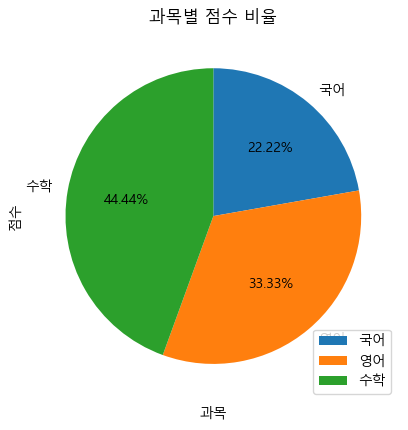

In [22]:
mylabel = chartdata03.index
chartdata03.plot(y='점수', kind='pie', labels=mylabel, shadow=False, \
         autopct='%1.2f%%', startangle=90, counterclock=False)
plt.grid(True)
plt.legend(loc=4)
plt.xlabel(chartdata03.index.name)
plt.title('과목별 점수 비율')

<h4><font color="green">merge() 메소드의 다양한 옵션</font></h4>	

<h6><font color="BlueViolet">how 옵션 사용해보기</font></h6>

In [23]:
result = pd.merge(student, jumsu, how='outer')
result

,id,이름,주소,과목,점수
0,choi,최윤라,강남,NaN,NaN
1,kang,강유심,마포,국어,10.0
2,kang,강유심,마포,영어,15.0
3,kang,강유심,마포,수학,20.0
4,shin,신서윤,용산,국어,25.0
5,shin,신서윤,용산,영어,30.0
6,shin,신서윤,용산,수학,30.0


In [24]:
result = pd.merge(student, jumsu, how='left')
result

,id,이름,주소,과목,점수
0,kang,강유심,마포,국어,10.0
1,kang,강유심,마포,영어,15.0
2,kang,강유심,마포,수학,20.0
3,shin,신서윤,용산,국어,25.0
4,shin,신서윤,용산,영어,30.0
5,shin,신서윤,용산,수학,30.0
6,choi,최윤라,강남,NaN,NaN


In [25]:
result = pd.merge(student, jumsu, how='right')
result

,id,이름,주소,과목,점수
0,kang,강유심,마포,국어,10
1,kang,강유심,마포,영어,15
2,kang,강유심,마포,수학,20
3,shin,신서윤,용산,국어,25
4,shin,신서윤,용산,영어,30
5,shin,신서윤,용산,수학,30


<h4><font color="green">데이터프레임의 컬럼 이름이 다른 경우</font></h4>	

In [26]:
file01 = './../data/학생정보02.csv'
student = pd.read_csv(file01, encoding='CP949')
student

,leftid,이름,주소
0,kang,강유심,마포
1,shin,신서윤,용산
2,choi,최윤라,강남


In [27]:
file02 = './../data/시험점수02.csv'
jumsu = pd.read_csv(file02, encoding='CP949')
jumsu

,rightid,과목,점수
0,kang,국어,10
1,kang,영어,15
2,kang,수학,20
3,shin,국어,25
4,shin,영어,30
5,shin,수학,30


<h6><font color="BlueViolet">left_on, right_on 옵션 사용</font></h6>

In [28]:
result = pd.merge(student, jumsu, left_on='leftid', right_on='rightid')
result

,leftid,이름,주소,rightid,과목,점수
0,kang,강유심,마포,kang,국어,10
1,kang,강유심,마포,kang,영어,15
2,kang,강유심,마포,kang,수학,20
3,shin,신서윤,용산,shin,국어,25
4,shin,신서윤,용산,shin,영어,30
5,shin,신서윤,용산,shin,수학,30


<h4><font color="green">여러 개의 컬럼 병합하기</font></h4>	

In [29]:
file01 = './../data/시험점수03.csv'
data01 = pd.read_csv(file01, encoding='CP949')
data01

,이름,과목,중간고사
0,강호섭,국어,10
1,강호섭,영어,15
2,강호섭,수학,20
3,윤진혁,국어,25
4,윤진혁,영어,30
5,윤진혁,수학,30


In [30]:
file02 = './../data/시험점수04.csv'
data02 = pd.read_csv(file02, encoding='CP949')
data02

,이름,과목,기말고사
0,강호섭,국어,15
1,강호섭,영어,25
2,강호섭,수학,35
3,윤진혁,국어,45
4,윤진혁,영어,55


<h6><font color="BlueViolet">on 옵션 사용해보기</font></h6>

In [31]:
# 양쪽 프레임에 동일 개념의 컬럼이 2개 이상인 경우
on_condition = ['이름', '과목']
print('여러 개의 컬럼 병합하기')
result = pd.merge(data01, data02, on=on_condition, how='outer')
result

여러 개의 컬럼 병합하기


,이름,과목,중간고사,기말고사
0,강호섭,국어,10,15.0
1,강호섭,수학,20,35.0
2,강호섭,영어,15,25.0
3,윤진혁,국어,25,45.0
4,윤진혁,수학,30,NaN
5,윤진혁,영어,30,55.0


<h6><font color="BlueViolet">on, how 옵션 사용해보기</font></h6>

In [32]:
file01 = './../data/시험점수05.csv'
data01 = pd.read_csv(file01, encoding='CP949')
data01

,이름,과목,시험
0,강호섭,국어,10
1,강호섭,영어,15
2,강호섭,수학,20
3,윤진혁,국어,25
4,윤진혁,영어,30
5,윤진혁,수학,30


In [33]:
file02 = './../data/시험점수06.csv'
data02 = pd.read_csv(file02, encoding='CP949')
data02

,이름,과목,시험
0,강호섭,국어,15
1,강호섭,영어,25
2,강호섭,수학,35
3,윤진혁,국어,45
4,윤진혁,영어,55


In [34]:
# 동일 컬럼 이름은 접미사 '_x', '_y'를 붙여 줍니다.
result = pd.merge(data01, data02, on=on_condition, how='outer')
result

,이름,과목,시험_x,시험_y
0,강호섭,국어,10,15.0
1,강호섭,수학,20,35.0
2,강호섭,영어,15,25.0
3,윤진혁,국어,25,45.0
4,윤진혁,수학,30,NaN
5,윤진혁,영어,30,55.0


<h6><font color="BlueViolet">동일 이름의 컬럼에 접미사 사용</font></h6>

In [35]:
result = pd.merge(data01, data02, on=on_condition, how='outer', \
                  suffixes=('_중간', '_기말'))
result

,이름,과목,시험_중간,시험_기말
0,강호섭,국어,10,15.0
1,강호섭,수학,20,35.0
2,강호섭,영어,15,25.0
3,윤진혁,국어,25,45.0
4,윤진혁,수학,30,NaN
5,윤진혁,영어,30,55.0


<h4><font color="green">색인 정보를 사용한 merge 기능</font></h4>	

<h6><font color="BlueViolet">학생의 시험 정보 읽기(index_col 옵션)</font></h6>

In [36]:
file01 = './../data/학생정보01.csv'
student = pd.read_csv(file01, encoding='CP949', index_col='id')
student

,이름,주소
id,,
kang,강유심,마포
shin,신서윤,용산
choi,최윤라,강남


In [37]:
file02 = './../data/시험점수01.csv'
jumsu = pd.read_csv(file02, encoding='CP949', index_col='id')
jumsu

,과목,점수
id,,
kang,국어,10
kang,영어,15
kang,수학,20
shin,국어,25
shin,영어,30
shin,수학,30


<h6><font color="BlueViolet">다양한 옵션 사용하기</font></h6>

In [38]:
result = pd.merge(student, jumsu, left_index=True, right_index=True, \
                  how='outer', indicator = True)
result

,이름,주소,과목,점수,_merge
id,,,,,
choi,최윤라,강남,NaN,NaN,left_only
kang,강유심,마포,국어,10.0,both
kang,강유심,마포,영어,15.0,both
kang,강유심,마포,수학,20.0,both
shin,신서윤,용산,국어,25.0,both
shin,신서윤,용산,영어,30.0,both
shin,신서윤,용산,수학,30.0,both


<h6><font color="BlueViolet">한쪽에 있는 데이터만 찾기(query 메소드)</font></h6>

In [39]:
# 왼쪽에 있는 데이터만 추출하기
m_result = result.query('_merge == "left_only"')
m_result

,이름,주소,과목,점수,_merge
id,,,,,
choi,최윤라,강남,NaN,NaN,left_only


<h4><font color="green">중첩 색인된 데이터 다루기</font></h4>	

<h6><font color="BlueViolet">중첩 색인된 데이터 만들기</font></h6>

In [40]:
import numpy as np

In [41]:
print('왼쪽 DataFrame')
left_frame = pd.DataFrame({
    '지역':['서울', '서울', '서울', '부산', '부산'],
    '년도':[2021, 2022, 2023, 2022, 2023],
    'data':[10 * idx for idx in range(1, 6)]
})
left_frame

왼쪽 DataFrame


,지역,년도,data
0,서울,2021,10
1,서울,2022,20
2,서울,2023,30
3,부산,2022,40
4,부산,2023,50


In [42]:
print('오른쪽 DataFrame')
myindex = [
    ['부산', '부산', '부산', '서울', '서울', '서울'], 
    [2022, 2021, 2023, 2021, 2022, 2023]
]
mycolumn = ['data01', 'data02']

data = np.arange(12).reshape((6, 2))

right_frame = pd.DataFrame(data, index=myindex, columns=mycolumn)
right_frame

오른쪽 DataFrame


data01  data02
부산 2022       0       1
   2021       2       3
   2023       4       5
서울 2021       6       7
   2022       8       9
   2023      10      11

<h6><font color="BlueViolet">merge 메소드로 병합하기</font></h6>

In [43]:
left_col = ['지역', '년도']
result = pd.merge(left_frame, right_frame, left_on=left_col, \
                 right_index=True, how='outer')
result

,지역,년도,data,data01,data02
4,부산,2021,NaN,2,3
3,부산,2022,40.0,0,1
4,부산,2023,50.0,4,5
0,서울,2021,10.0,6,7
1,서울,2022,20.0,8,9
2,서울,2023,30.0,10,11


<h2><font color="red">형상 변경하기</font></h2>

<h4><font color="green">과일 구매 내역 정보 읽기(pivot)</font></h4>

In [44]:
import pandas as pd

In [45]:
filename = './../data/pivotFile.csv'
data = pd.read_csv(filename, encoding='UTF-8', header=0)
data

,name,item,value,qty
0,kim,apple,100,10
1,kim,orange,200,20
2,kim,peach,300,30
3,park,apple,100,40
4,park,orange,500,50
5,park,peach,600,60


<h6><font color="BlueViolet">긴 형식 데이터를 넓은 형식으로 변환</font></h6>

In [46]:
# 긴 형식(long format)의 데이터를 넓은 형식(wide format)으로 변환합니다.
pivotData = data.pivot(index='name', columns='item', values='value')
pivotData

item,apple,orange,peach
name,,,
kim,100,200,300
park,100,500,600


<h6><font color="BlueViolet">2개 이상의 컬럼도 가능</font></h6>

In [47]:
pivotData = data.pivot(index='name', columns='item', values=['value', 'qty'])
pivotData

value                qty             
item apple orange peach apple orange peach
name                                      
kim    100    200   300    10     20    30
park   100    500   600    40     50    60

<h4><font color="green">직원별 월별 실적(melt)</font></h4>

<h6><font color="BlueViolet">데이터 읽기</font></h6>

In [48]:
filename = './../data/meltsheet.csv'
siljuk = pd.read_csv(filename, encoding='CP949')
siljuk

,이름,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,강감찬,59,92,66,98,59,70,77,67,88,61,57,52
1,홍길동,90,96,56,92,95,54,80,62,64,65,90,73
2,이순신,65,70,74,60,57,76,61,53,79,95,61,75
3,김유신,93,67,90,82,98,61,80,95,83,80,88,86


<h6><font color="BlueViolet">직원별 월별 실적 그래프</font></h6>

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

In [50]:
chartdata=siljuk.copy()
chartdata=chartdata.set_index('이름').T

Text(0.5, 1.0, '직원별 월별 꺽은 선')

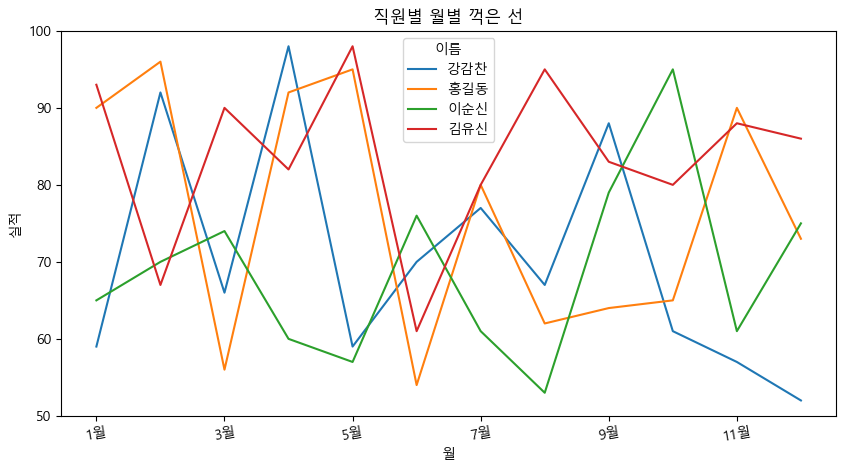

In [51]:
chartdata.plot(kind='line', figsize=(10, 5), ylim=[50, 100], grid=False, \
                rot=10, use_index=True)
plt.xlabel('월')
plt.ylabel('실적')
plt.title('직원별 월별 꺽은 선')

<h6><font color="BlueViolet">넓은 형식 데이터를 긴 형식으로 변환</font></h6>

In [52]:
siljuk_long = pd.melt(siljuk, id_vars =['이름'],
                var_name='월', value_name = '실적')
siljuk_long.head(8)

,이름,월,실적
0,강감찬,1월,59
1,홍길동,1월,90
2,이순신,1월,65
3,김유신,1월,93
4,강감찬,2월,92
5,홍길동,2월,96
6,이순신,2월,70
7,김유신,2월,67


<h6><font color="BlueViolet">특정인만 조회해 보기</font></h6>

In [53]:
result = siljuk_long.loc[siljuk_long['이름'] == '이순신']
result

,이름,월,실적
2,이순신,1월,65
6,이순신,2월,70
10,이순신,3월,74
14,이순신,4월,60
18,이순신,5월,57
22,이순신,6월,76
26,이순신,7월,61
30,이순신,8월,53
34,이순신,9월,79
38,이순신,10월,95


<h6><font color="BlueViolet">특정월만 조회해 보기</font></h6>

In [54]:
result = siljuk_long.loc[siljuk_long['월'] == '4월']
result

,이름,월,실적
12,강감찬,4월,98
13,홍길동,4월,92
14,이순신,4월,60
15,김유신,4월,82


In [55]:
# isin() 함수는 특정 조건에 만족하는 데이터에 대하여 True를 반환해주는 함수입니다.
# 데이터 베이스의 in 키워드와 유사한 개념입니다.
filter_dict = {'월':['1월', '3월']}
condition = siljuk_long.isin(filter_dict)
condition

,이름,월,실적
0,False,True,False
1,False,True,False
2,False,True,False
3,False,True,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,True,False
9,False,True,False


In [56]:
result = siljuk_long.loc[condition['월'] ]
result

,이름,월,실적
0,강감찬,1월,59
1,홍길동,1월,90
2,이순신,1월,65
3,김유신,1월,93
8,강감찬,3월,66
9,홍길동,3월,56
10,이순신,3월,74
11,김유신,3월,90


<h4><font color="green">영화 매출 데이터(pivot_table)</font></h4>

<h6><font color="BlueViolet">영화 데이터 읽기</font></h6>

In [57]:
movshow = pd.read_csv('./../data/movie_show.csv', encoding='CP949')
movshow

,gu,year,month,드라마,공포,액션
0,마포구,2020,1,10,20,10
1,용산구,2020,1,20,20,30
2,마포구,2020,2,30,10,10
3,용산구,2020,2,30,30,20
4,마포구,2020,3,10,20,10
5,용산구,2020,3,20,20,30


<h6><font color="BlueViolet">장르별 매출 분류하기</font></h6>

In [58]:
movshow_melt = pd.melt(movshow, id_vars=['gu', 'year', 'month'], \
                       var_name='genre', value_name='qty')
movshow_melt.head()

,gu,year,month,genre,qty
0,마포구,2020,1,드라마,10
1,용산구,2020,1,드라마,20
2,마포구,2020,2,드라마,30
3,용산구,2020,2,드라마,30
4,마포구,2020,3,드라마,10


<h6><font color="BlueViolet">구별, 년도별 월 매출 평균, 총합</font></h6>

In [59]:
# pivot_table() : 데이터를 재구성하여 요약된 형태로 표현(그룹화, 집계, 정리 등)하는 데 사용됩니다. 
# 특정 지역의 특정 월에 대하여 상영 회수의 평균 값을 보여 줍니다.
# aggfunc는 집계 함수(aggregate function)를 의미합니다.
movshow_tidy = movshow_melt.pivot_table(index=['gu', 'year'], columns='month', values='qty', aggfunc='mean')
movshow_tidy

,month,1,2,3
gu,year,,,
마포구,2020,13.333333,16.666667,13.333333
용산구,2020,23.333333,26.666667,23.333333


In [60]:
movshow_tidy = movshow_melt.pivot_table(index=['gu', 'year'], columns='month', values='qty', aggfunc='sum')
movshow_tidy # 총합

,month,1,2,3
gu,year,,,
마포구,2020,40,50,40
용산구,2020,70,80,70


<h6><font color="BlueViolet">2개 이상의 컬럼에 대한 집계</font></h6>

In [61]:
dict_aggfunc = {'genre':'count', 'qty':'mean'}

movshow_tidy = movshow_melt.pivot_table(
    index=['gu', 'year'], 
    columns='month', 
    values=['genre', 'qty'], 
    aggfunc=dict_aggfunc)
movshow_tidy

genre              qty                      
month        1  2  3          1          2          3
gu  year                                             
마포구 2020     3  3  3  13.333333  16.666667  13.333333
용산구 2020     3  3  3  23.333333  26.666667  23.333333

In [62]:
# 특정 컬럼 1개에 대하여 여러 개의 함수를 적용합니다.
dict_aggfunc = {'qty':['mean', 'sum']}

movshow_tidy = movshow_melt.pivot_table(
    index=['gu', 'year'], 
    columns='genre', 
    values='qty', 
    aggfunc=dict_aggfunc)
movshow_tidy

mean                       sum        
genre            공포        드라마         액션  공포 드라마  액션
gu  year                                             
마포구 2020  16.666667  16.666667  10.000000  50  50  30
용산구 2020  23.333333  23.333333  26.666667  70  70  80

<h6><font color="BlueViolet">충첩 열 색인의 단순화(simplification)</font></h6>

In [63]:
# 내부와 외부 색인 사이에 언더바를 붙여서 renaming하기
outer = movshow_tidy.columns.get_level_values(0) # 외부 색인
inner = movshow_tidy.columns.get_level_values(1) # 내부 색인
print(outer, inner)
newColumns = inner + '_' + outer
movshow_tidy.columns = newColumns
movshow_tidy

Index(['mean', 'mean', 'mean', 'sum', 'sum', 'sum'], dtype='object') Index(['공포', '드라마', '액션', '공포', '드라마', '액션'], dtype='object', name='genre')


,,공포_mean,드라마_mean,액션_mean,공포_sum,드라마_sum,액션_sum
gu,year,,,,,,
마포구,2020,16.666667,16.666667,10.000000,50,50,30
용산구,2020,23.333333,23.333333,26.666667,70,70,80


In [64]:
# outer = movshow_tidy.index.get_level_values(0) # 외부 색인
# inner = movshow_tidy.index.get_level_values(1) # 내부 색인
# outer, inner
# newindex = inner + '_' + outer
# movshow_tidy.index = newindex
# movshow_tidy

<h6><font color="BlueViolet">충첩 행색인을 숫자 형식으로 재색인</font></h6>

In [65]:
# 현재 설정된 인덱스를 0부터 시작하는 정수 인덱스로 다시 설정합니다. 
result = movshow_tidy.reset_index()
result

,gu,year,공포_mean,드라마_mean,액션_mean,공포_sum,드라마_sum,액션_sum
0,마포구,2020,16.666667,16.666667,10.000000,50,50,30
1,용산구,2020,23.333333,23.333333,26.666667,70,70,80


In [66]:
result = movshow_tidy.reset_index(drop=True)
result

,공포_mean,드라마_mean,액션_mean,공포_sum,드라마_sum,액션_sum
0,16.666667,16.666667,10.000000,50,50,30
1,23.333333,23.333333,26.666667,70,70,80
